# Generate Raytracing-Based CSI Dataset

## Imports and Directory Setup

In [1]:
!mkdir results

mkdir: cannot create directory ‘results’: File exists


In [2]:
# Import or install Sionna
try:
    import sionna.rt
except ImportError as e:
    import os
    os.system("pip install sionna-rt")
    import sionna.rt

# Other imports
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
import tqdm

# Import relevant components from Sionna RT
from sionna.rt import load_scene, PlanarArray, Transmitter, Receiver, Camera,\
                      PathSolver, subcarrier_frequencies

2026-02-09 12:31:19.716022: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1770640279.741665    6062 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1770640279.749541    6062 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1770640279.770079    6062 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770640279.770097    6062 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770640279.770100    6062 computation_placer.cc:177] computation placer alr

## Set up Scene

In [3]:
# Load scene based on 3d model
scene = load_scene("dataset/arena2036_simple_metalcube.xml")

row_nr = 8
col_nr = 8

scene.frequency = 3.438e9 # in Hz; implicitly updates RadioMaterials that implement frequency dependent properties

# Configure antenna array for all transmitters
scene.tx_array = PlanarArray(num_rows=1,
                             num_cols=1,
                             vertical_spacing = 0.5, # multiples of wavelength
                             horizontal_spacing = 0.5, # multiples of wavelength
                             pattern="dipole",
                             polarization="V")

# Configure antenna array for all receivers, assuming that all of the RX arrays have the same number of rows and columns
scene.rx_array = PlanarArray(num_rows = row_nr,
                             num_cols = col_nr,
                             vertical_spacing = 0.5, # multiples of wavelength
                             horizontal_spacing = 0.5, # multiples of wavelength
                             pattern="tr38901",
                             polarization="V")

# Materials of scene objects
for i, obj in enumerate(scene.objects.values()):
    print(f"{obj.name} : {obj.radio_material.name}")

no-name-1 : itu_metal
SceneObject_Glass : itu_glass
SceneObject_Wood : itu_wood
SceneObject_Plastic : itu_plasterboard
SceneObject_Concrete : itu_concrete
SceneObject_Brick : itu_brick


### Add BS arrays

In [4]:
# RX positions
array_positions = np.asarray([[-9, -2, 2],
                           [-9, -2, 8],
                           [-3, -2, 2],
                           [-3, -2, 8],
                           [-20, -13, 2],
                           [-20, -13, 8],
                           [-20, -19, 2],
                           [-20, -19, 8]])

# Center position for all arrays to look at
center_position = np.asarray([-6,-16,5])

# Add RX arrays to scene
for i in range(array_positions.shape[0]):
    rx = Receiver(name=f"rx_{i}",
                  position = array_positions[i],
                  look_at = center_position,
                  display_radius=0.3)
    scene.add(rx)

In [5]:
# Save array positions and center position for following notebooks
np.save('dataset/array_positions.npy', array_positions)
np.save('dataset/center_position.npy', center_position)

### Define L-shaped Area and Number of Datapoints

In [6]:
# Generate a large number of random points within the overall bounding box
num_points = 5000

# Define the boundaries of the two rectangles that form the new L-shape
# The L-shape is the area within the bounding box with a rectangular cutout at the top-left
x_bound_min, x_bound_max = -19, -3
y_bound_min, y_bound_max = -19, -3
z_min, z_max = 2, 8

# Define the boundaries of the cutout rectangle
x_cutout_min = -19
x_cutout_max = -9
y_cutout_min = -13
y_cutout_max = -3

## Create CSI Dataset
-> This may take a few minutes...

In [7]:
# OFDM system parameters
bandwidth = 50e6
num_subcarriers = 64
subcarrier_spacing = bandwidth / num_subcarriers

# Compute frequencies of subcarriers relative to the carrier frequency
frequencies = subcarrier_frequencies(num_subcarriers, subcarrier_spacing)

# Instantiate a path solver
p_solver  = PathSolver()

# Compute CSI and corresponding positions for training set
groundtruth_positions_train = []

def _bytes_feature(value):
    """Returns a bytes_list from a tensor."""
    value = tf.io.serialize_tensor(value)
    if isinstance(value, type(tf.constant(0))):
        value = value.numpy() # BytesList won't unpack a string from an EagerTensor.
    return tf.train.Feature(bytes_list=tf.train.BytesList(value=[value]))


with tf.io.TFRecordWriter("dataset/training_set.tfrecords") as tfwriter:

    # progress bar
    pbar = tqdm.tqdm(total=num_points, desc="Generating Datapoints")

    # Set counter for number of generated points and number of points with zero-magnitude entries in CSI
    i = 0
    zero_counter = 0
    while i < num_points:
        
        # Generate random position in area
        x_coords = np.random.uniform(x_bound_min, x_bound_max)
        y_coords = np.random.uniform(y_bound_min, y_bound_max)
        z_coords = np.random.uniform(z_min, z_max)
        
        # Filter the points to keep only those that are outside the cutout and inside the main bounding box
        is_in_cutout = (x_coords >= x_cutout_min) & (x_coords <= x_cutout_max) & (y_coords >= y_cutout_min) & (y_coords <= y_cutout_max)
        
        if is_in_cutout:
            continue

        random_pos = np.asarray([x_coords, y_coords, z_coords])
    
        # Add TX at random position to scene
        tx = Transmitter(name="tx", position=random_pos)
        scene.add(tx)
    
        # Compute propagation paths
        paths = p_solver(scene=scene,
                         max_depth=5,
                         los=True,
                         specular_reflection=True,
                         diffuse_reflection=True,
                         refraction=True,
                         synthetic_array=True)
    
        # Compute channel frequency response
        h_freq = paths.cfr(frequencies=frequencies,
                           normalize=False,
                           normalize_delays=True,
                           out_type="numpy").squeeze()

        h_freq = np.moveaxis(h_freq.reshape(h_freq.shape[0], col_nr, row_nr, h_freq.shape[-1]), 1, 2)

        # Check if CSI contains any zero-magnitude entries
        if np.any(np.abs(h_freq.flatten()) == 0.0):
            zero_counter += 1
            scene.remove("tx")
            continue
    
        groundtruth_positions_train.append(random_pos)
        
        # Write data to tfrecords file
        feature = {
            "csi": _bytes_feature(np.stack([np.real(h_freq), np.imag(h_freq)], axis = -1)),
            "pos": _bytes_feature(random_pos)
        }
        example = tf.train.Example(features=tf.train.Features(feature=feature)).SerializeToString()
        tfwriter.write(example)
    
        # Remove TX from scene
        scene.remove("tx")

        # Increment counter
        i += 1

        # Increment progress bar
        pbar.update(1)

    # close progress bar
    pbar.close()

# Print final count of zero-magnitude CSI entries and total number of generated datapoints
print("CSI samples with zero magnitude entries: {}".format(zero_counter))
print("Total number of generated datapoints: {}".format(i))

Generating Datapoints:  19%|█▉        | 974/5000 [01:30<06:09, 10.90it/s]/opt/conda/lib/python3.12/site-packages/drjit/ast.py:838: RuntimeWarning: The AST-transforming decorator @drjit.syntax was called more than 1000 times by your program. Since transforming and recompiling Python code is a relatively expensive operation, it should not be used within loops or subroutines. Please move the function to be transformed to the top program level and decorate it there.
  warnings.warn(
Generating Datapoints: 100%|██████████| 5000/5000 [07:07<00:00, 11.70it/s]


CSI samples with zero magnitude entries: 0
Total number of generated datapoints: 5000


In [8]:
# Convert list of positions to numpy array
groundtruth_positions_train = np.asarray(groundtruth_positions_train)
print(groundtruth_positions_train.shape)

(5000, 3)


## Visualize Groundtruth Positions

### Scatter Plot with Color Gradient

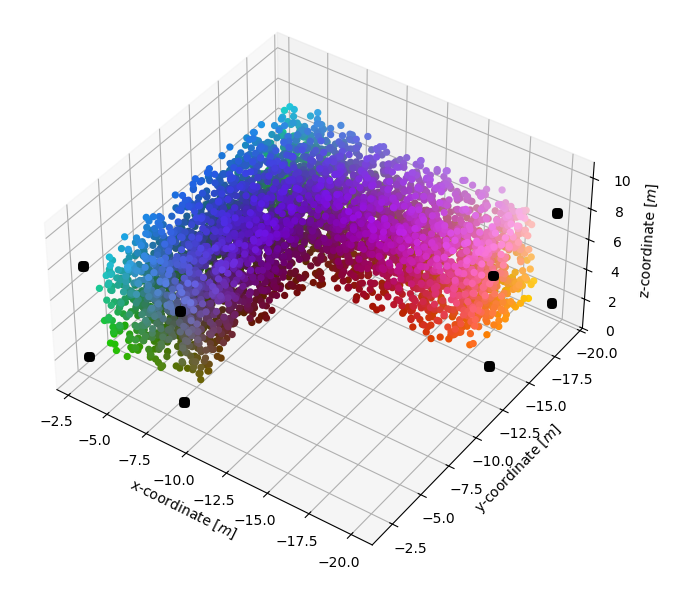

In [9]:
%matplotlib widget 

def plot_colorized(positions, groundtruth_positions, title = None, alpha = 1.0, save_path = None):
    # Generate RGB colors for datapoints
    center_point = np.zeros(3, dtype = np.float32)
    center_point[0] = 0.5 * (np.min(groundtruth_positions[:, 0], axis = 0) + np.max(groundtruth_positions[:, 0], axis = 0))
    center_point[1] = 0.5 * (np.min(groundtruth_positions[:, 1], axis = 0) + np.max(groundtruth_positions[:, 1], axis = 0))
    center_point[2] = 0.5 * (np.min(groundtruth_positions[:, 2], axis = 0) + np.max(groundtruth_positions[:, 2], axis = 0))
    NormalizeData = lambda in_data : (in_data - np.min(in_data)) / (np.max(in_data) - np.min(in_data))
    rgb_values = np.zeros((groundtruth_positions.shape[0], 3))
    rgb_values[:, 0] = 1 - 0.9 * NormalizeData(groundtruth_positions[:, 0])
    rgb_values[:, 1] = 0.8 * NormalizeData(np.square(np.linalg.norm(groundtruth_positions - center_point, axis=1)))
    rgb_values[:, 2] = 0.9 * NormalizeData(groundtruth_positions[:, 2])

    # Plot datapoints
    ax = plt.figure(figsize=(7,6)).add_subplot(projection='3d')
    ax.scatter(positions[:, 0], positions[:, 1], positions[:, 2], c = rgb_values, s = 5, alpha = alpha, linewidths = 3)

    ax.scatter(array_positions[:,0], array_positions[:,1], array_positions[:,2], marker = 's', s = 7, c = 'black', alpha = 1, linewidth = 5)
    
    ax.set_zlim(0,11)
    ax.set_xlabel('x-coordinate $[m]$')
    ax.set_ylabel('y-coordinate $[m]$')
    ax.set_zlabel('z-coordinate $[m]$')

    ax.set_box_aspect([np.ptp(groundtruth_positions[:, 0]), np.ptp(groundtruth_positions[:, 1]), 1.5*np.ptp(groundtruth_positions[:, 2])])
    
    # Customize the view angle so it's easier to see that the scatter points lie
    # on the plane y=0
    ax.view_init(elev=40., azim=125, roll=0)
    plt.tight_layout()
    plt.subplots_adjust(left=-0.05, right=0.95, top=1.0, bottom=0.05)
    if save_path is not None:
        plt.savefig(save_path, dpi=600)
    plt.show()

plot_colorized(groundtruth_positions_train, groundtruth_positions_train, title = None, alpha = 1.0, save_path = "results/groundtruth_positions.png")

### Scatter Plot of Positions within Scene

rendering...


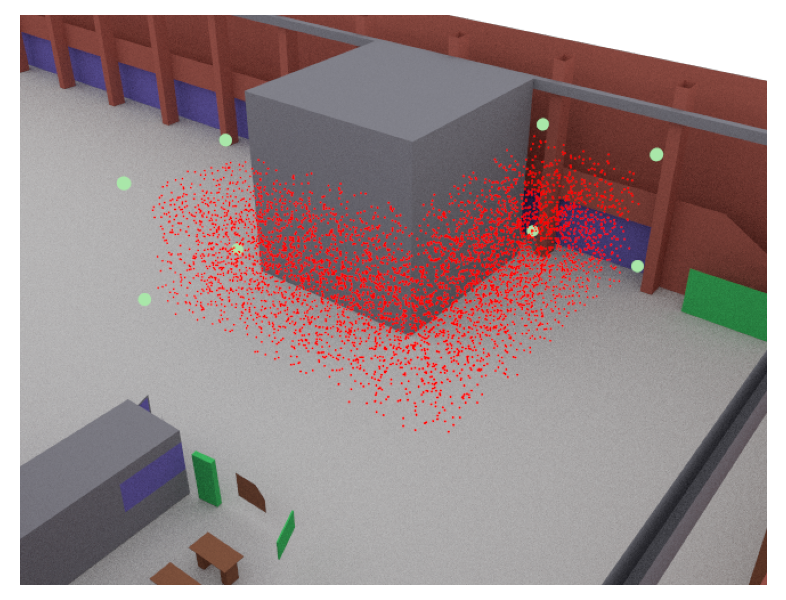

In [10]:
# Add TX
for i in range(groundtruth_positions_train.shape[0]):
    tx = Transmitter(name=f"tx_{i}",
                  position = groundtruth_positions_train[i],
                  display_radius=0.05)
    scene.add(tx)

# Render scene
print("rendering...")
my_cam = Camera(position=[11,-40,25], look_at=[-6,-18,7])
scene.render(camera=my_cam, clip_at=11);

In [11]:
# Save rendered scene
scene.render_to_file(camera=my_cam, filename="results/scene.png", clip_at=11, resolution=[1300,1000]);